In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dynesty
import corner
from dynesty import plotting as dyplot

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

## Time to get your hands dirty.  The transient Universe

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*



Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

In [2]:
data = np.load('../solutions/transient.npy')

In [3]:
t, f, ferr = data.T
values = t, f, ferr

In [4]:
def model(t,A,b,alpha,t0):
    y = np.ones_like(t)*b
    y[t>t0] += A*np.exp(-alpha*(t[t>t0]-t0))
    return y

# with correct normalization!
def logl(theta,t, f, ferr):
    A,b,alpha,t0 = theta
    normal = np.log(1./np.sqrt(2*np.pi*ferr**2))
    return np.sum(normal -1./2.*(((f-model(t,A,b,alpha,t0))/ferr)**2))

def ptform(theta):
    """Transforms samples drawn from the unit cube to samples to those
    from our priors"""
    A_prime,b_prime,log_alpha_prime,t0_prime = theta
    bmin = Amin = t0min = 0.
    bmax = Amax = 50.
    t0max = 100.
    logalphamin = -5.
    logalphamax = 5.

    A = A_prime*(Amax-Amin) + Amin
    b = b_prime*(bmax-bmin) + bmin
    t0 = t0_prime*(t0max-t0min) + t0min
    logalpha = log_alpha_prime*(logalphamax-logalphamin) + logalphamin
    alpha = np.exp(logalpha)

    return(A,b,alpha,t0)

In [5]:
ndim = 4

# "Static" nested sampling.
sampler = dynesty.NestedSampler(logl, ptform, ndim, logl_args=values)
sampler.run_nested()
sresults = sampler.results

4066it [00:12, 82.41it/s, bound: 122 | nc: 430 | ncall: 87906 | eff(%):  4.625 | loglstar:   -inf < -176.806 <    inf | logz: -185.019 +/-  0.108 | dlogz: 36.109 >  0.509] /opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
4197it [00:13, 107.45it/s, bound: 135 | nc: 16 | ncall: 97220 | eff(%):  4.317 | loglstar:   -inf < -175.022 <    inf | logz: -184.518 +/-  0.116 | dlogz: 35.350 >  0.509] /opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrappi

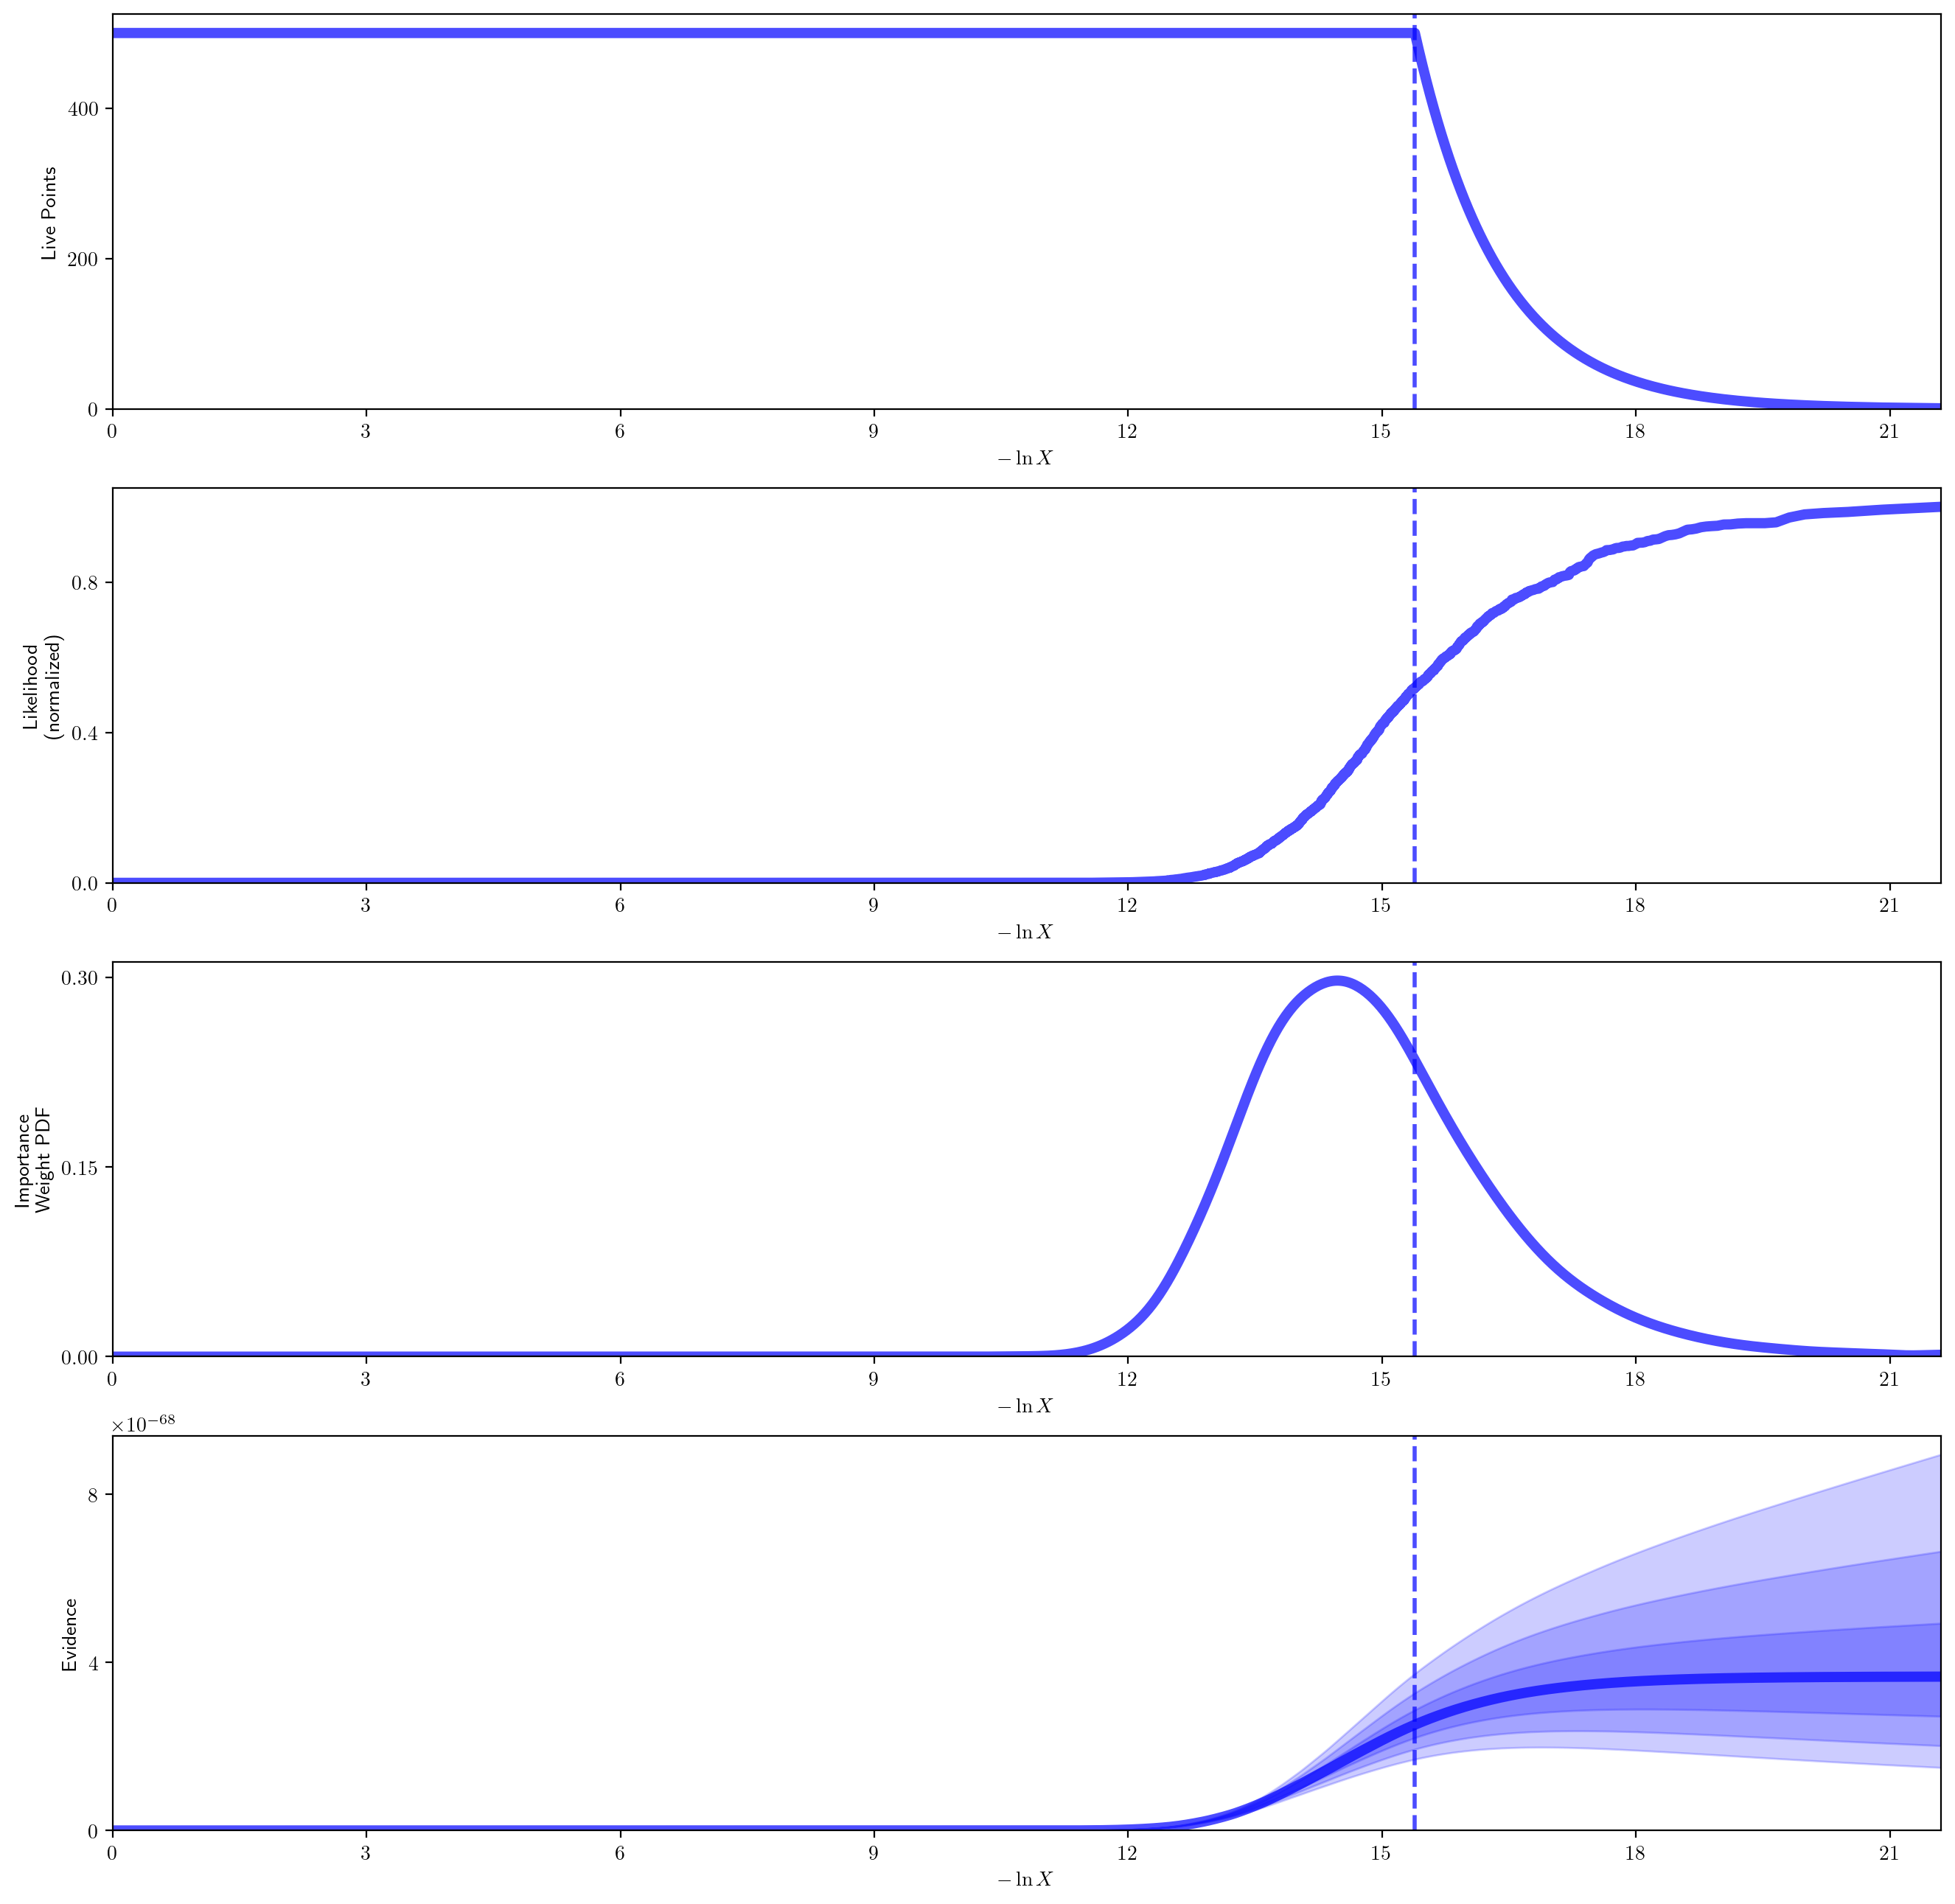

In [6]:
# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

Text(0.5, 0.98, 'Parameter traces')

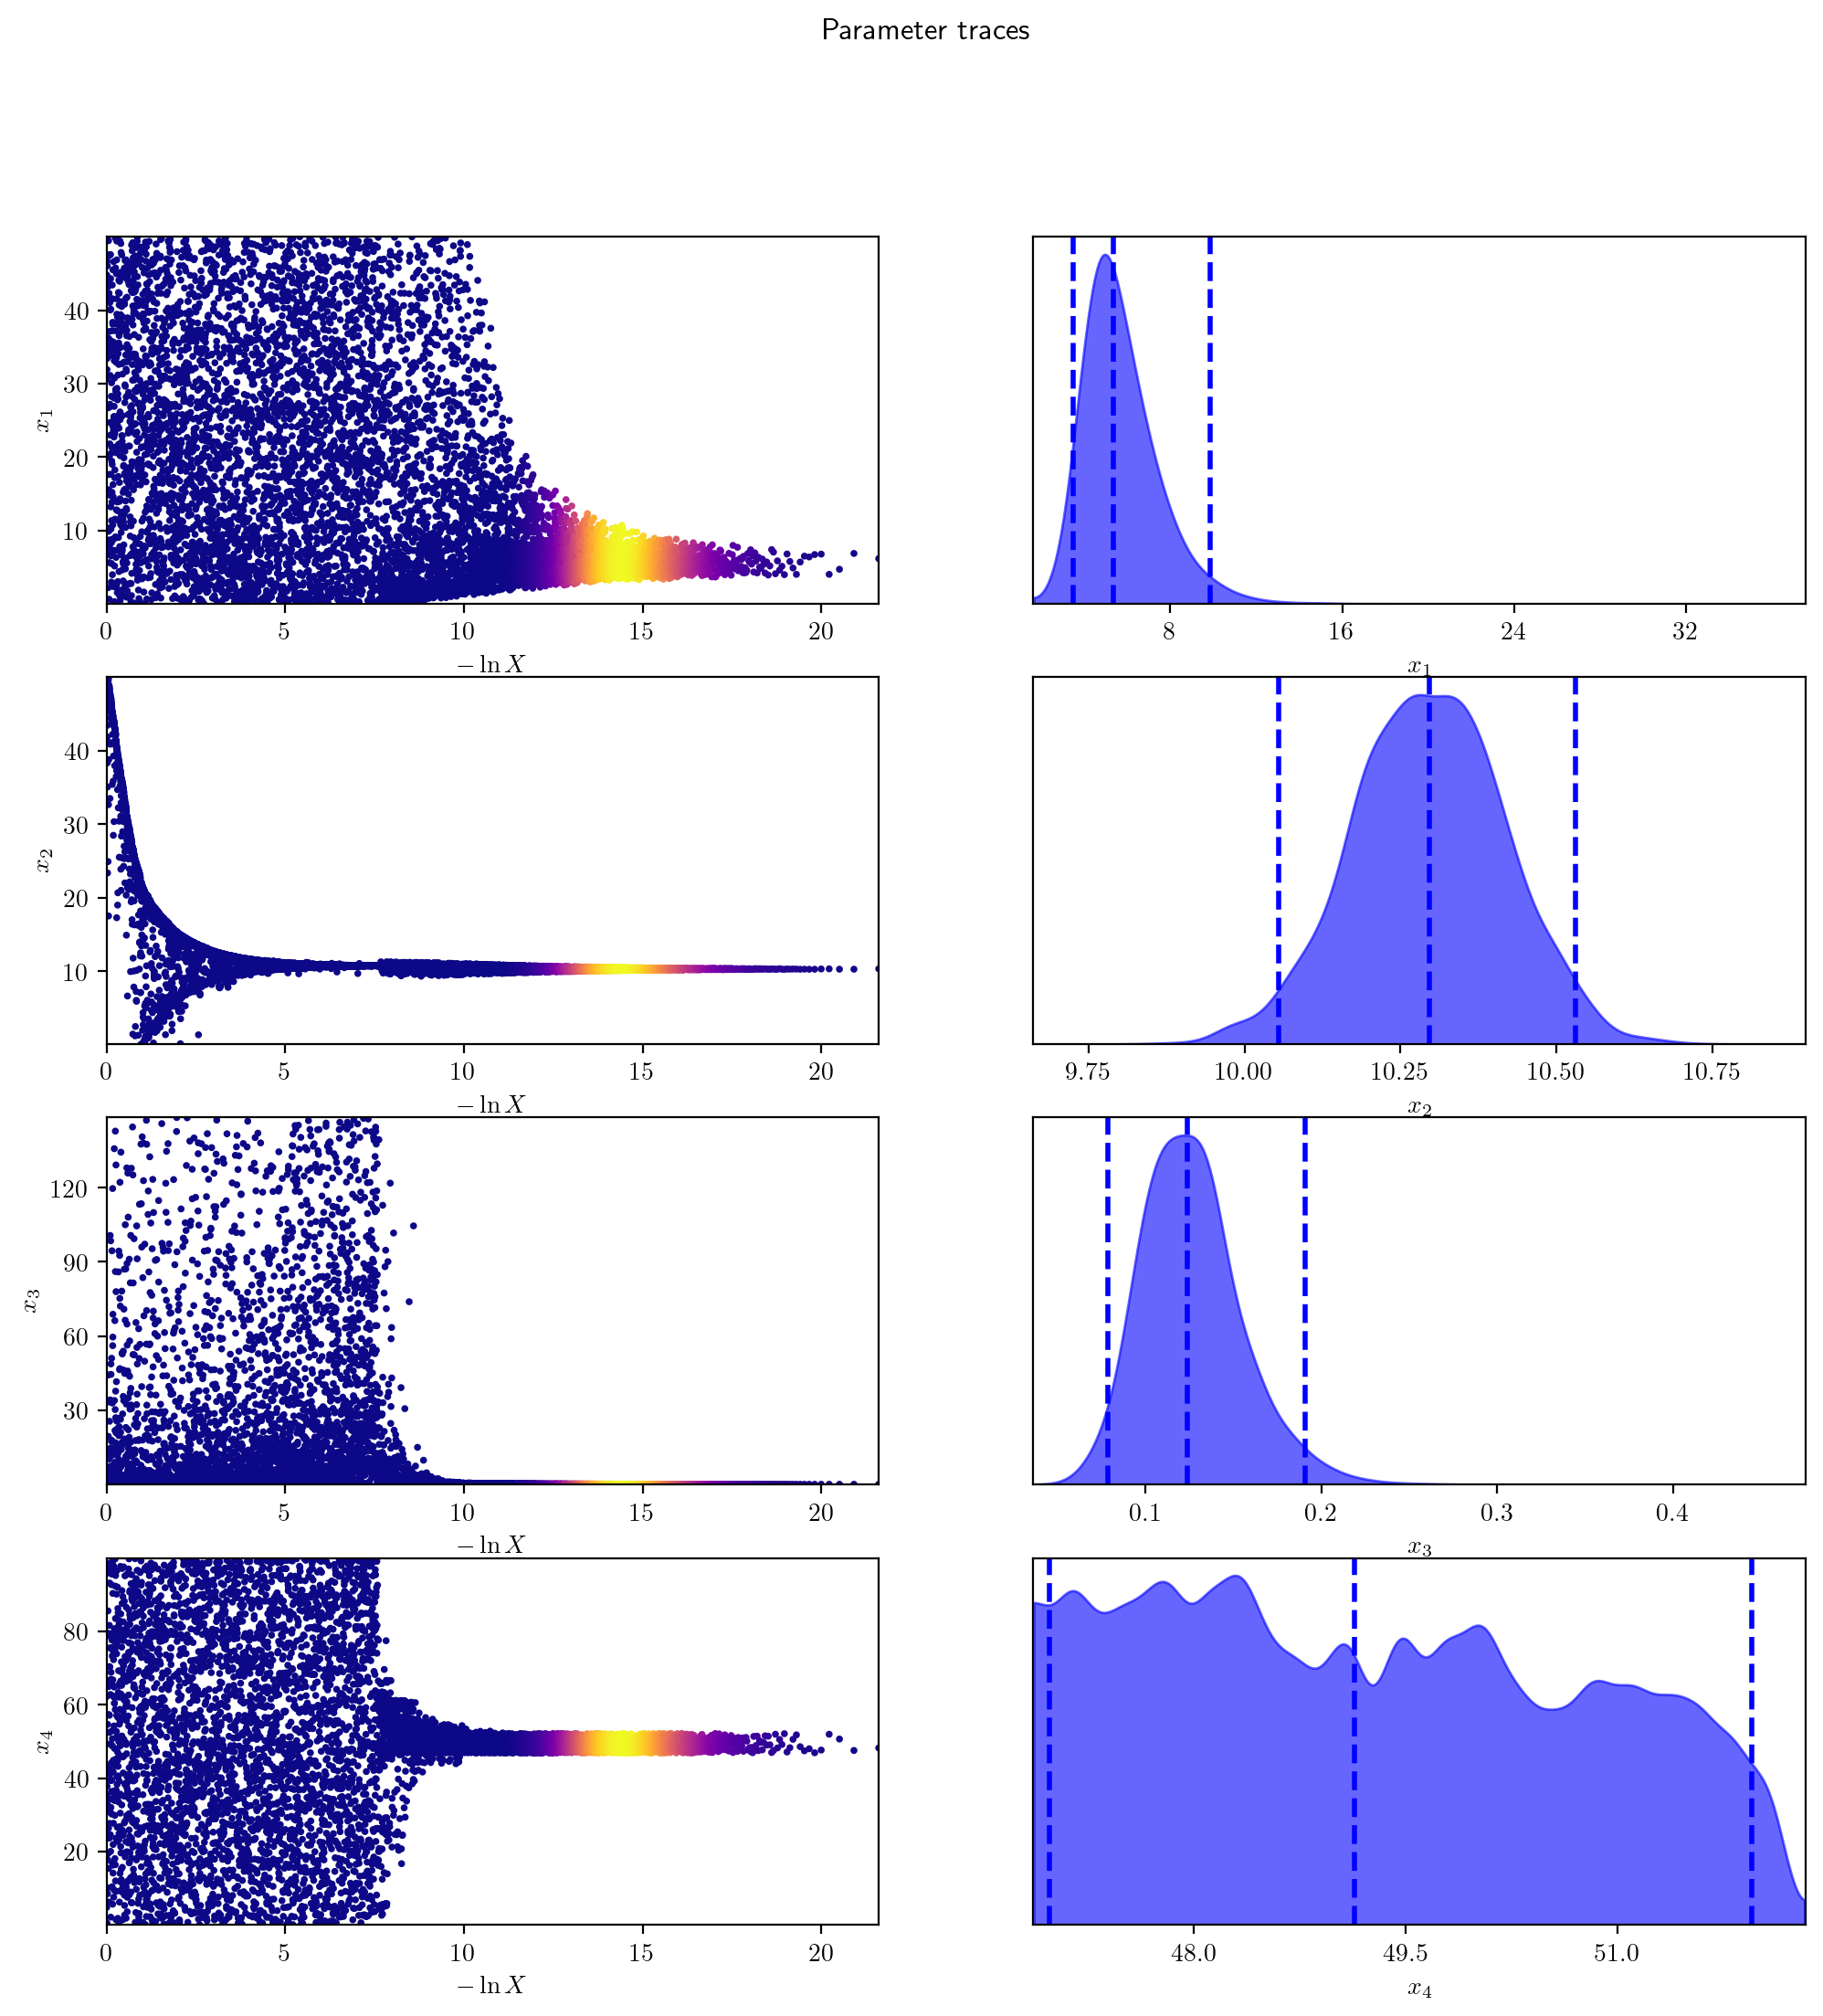

In [7]:
tfig, taxes = dyplot.traceplot(sresults)
plt.suptitle('Parameter traces')

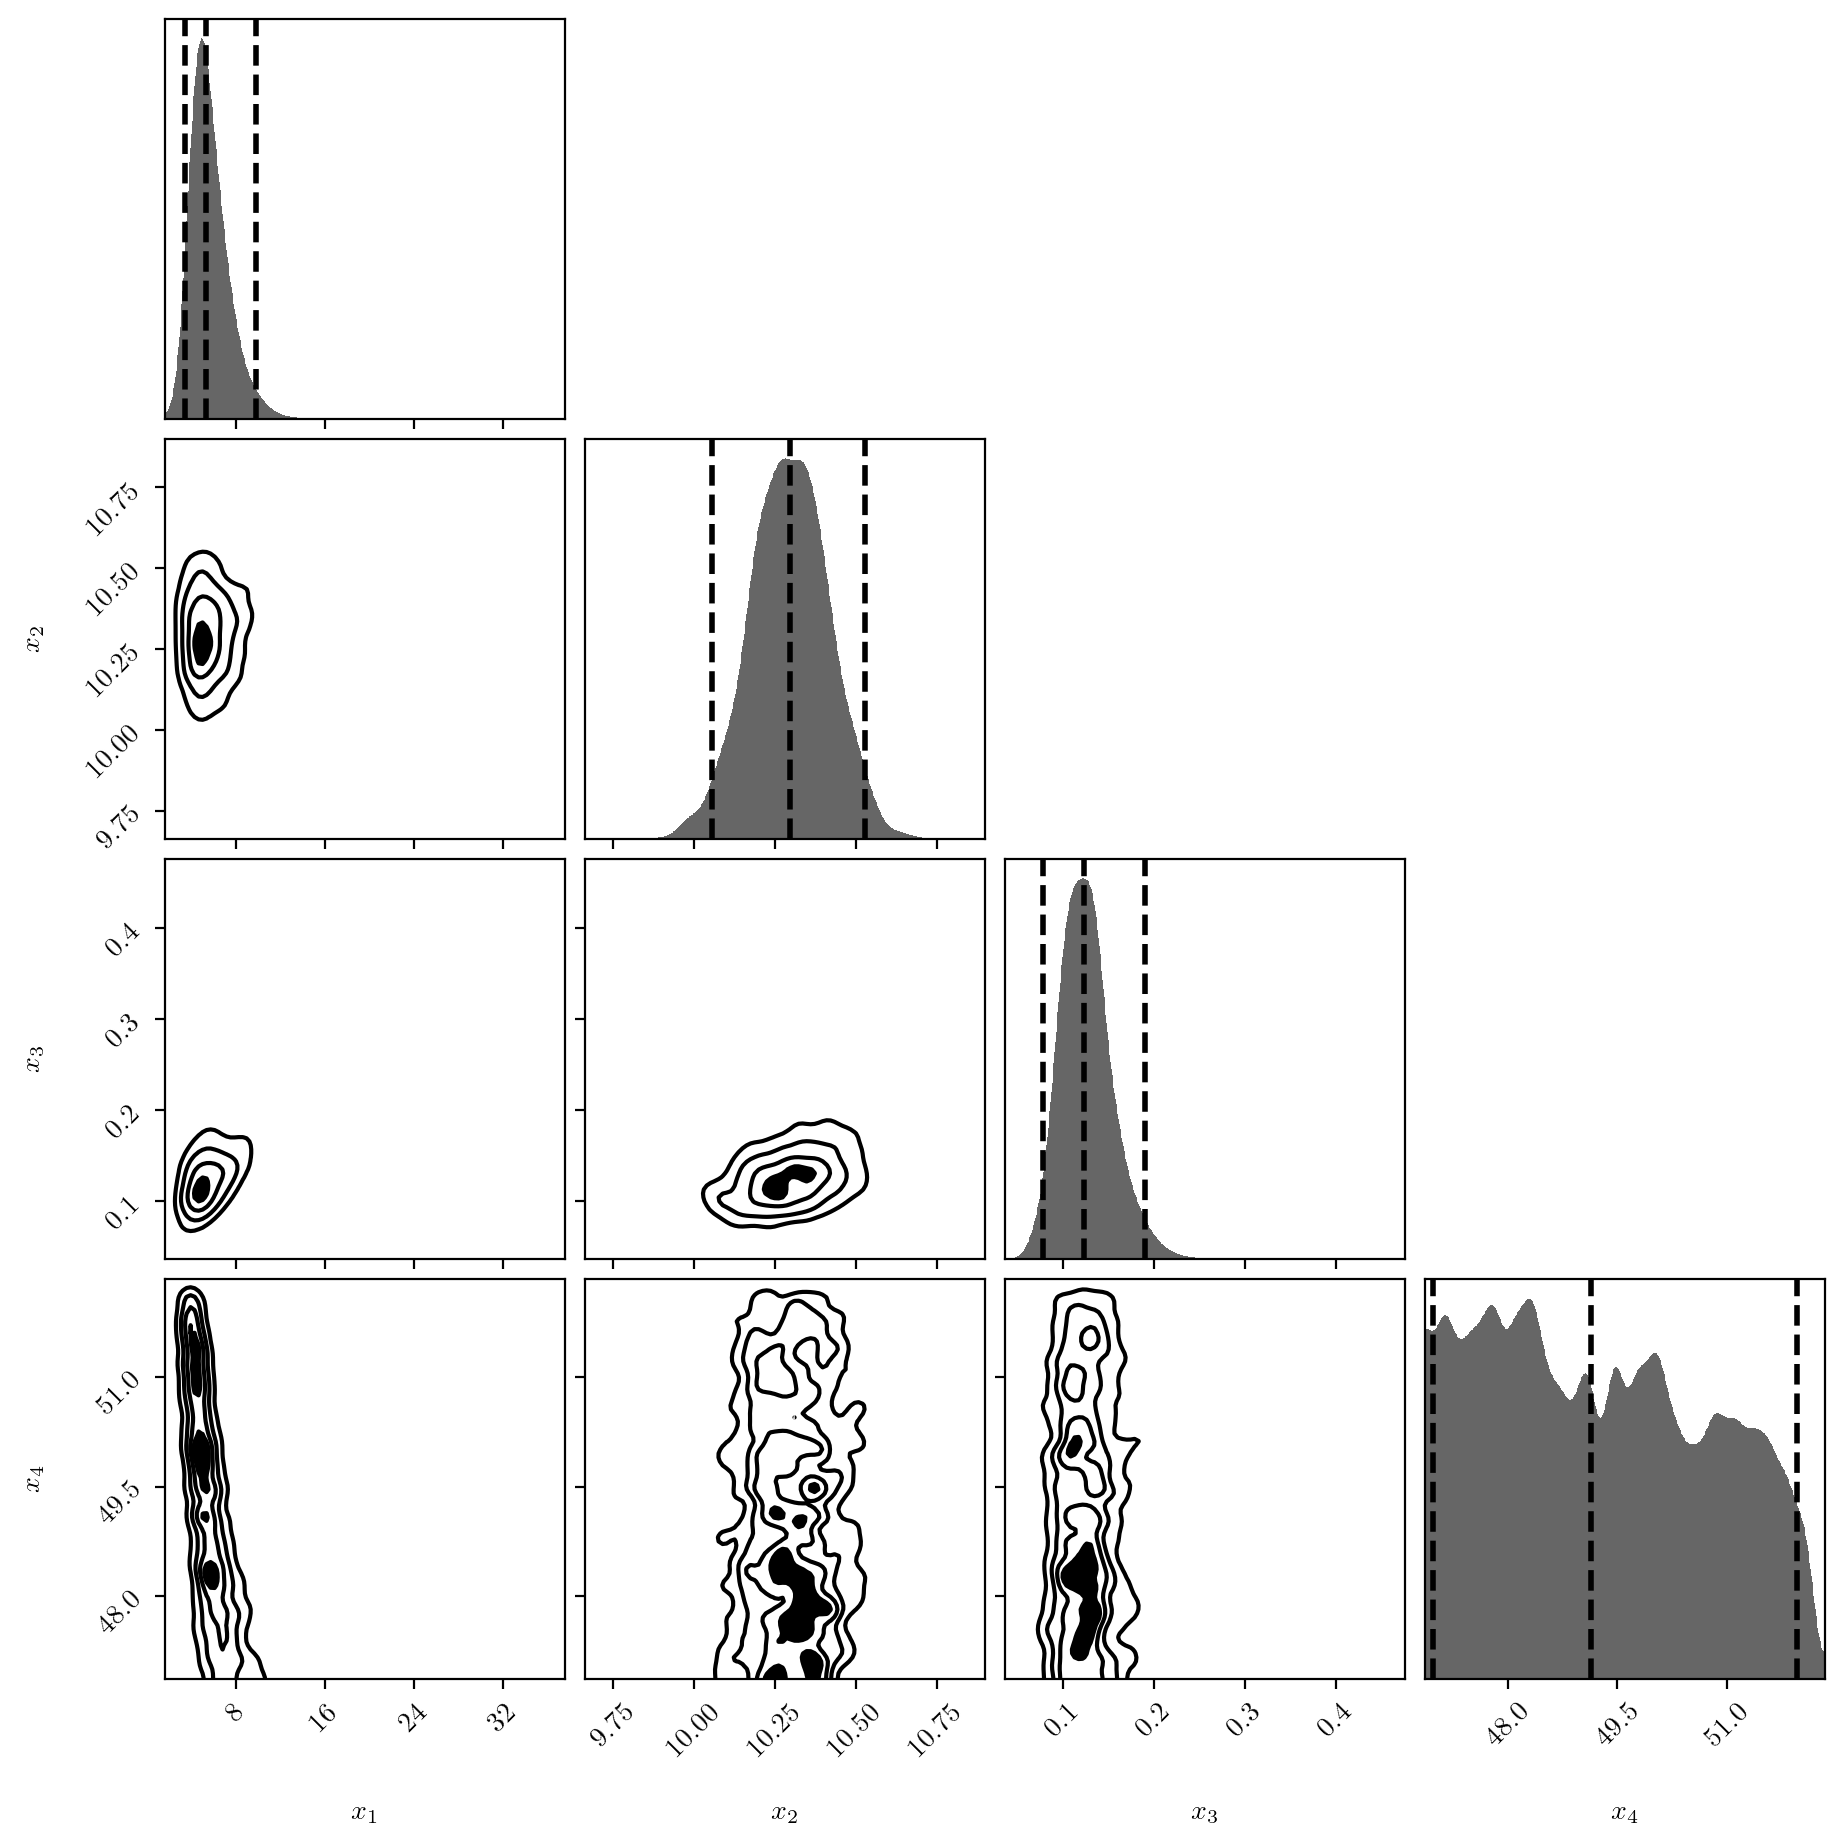

In [8]:
cfig, caxes = dyplot.cornerplot(sresults)

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)


In [9]:
def model_gaussian(t,A,b,t0,sw):
    y = b + A*np.exp(-(t-t0)**2/(2*sw**2))
    return y

def logl_g(theta,t, f, ferr):
    A,b,t0,sw = theta
    normal = np.log(1./np.sqrt(2*np.pi*ferr**2))
    return np.sum(normal -1./2.*(((f-model_gaussian(t,A,b,t0,sw))/ferr)**2))

def ptform_g(theta):
    # adopting scale invariance (to check)
    A_prime,b_prime, t0_prime, log_sw_prime = theta
    bmin = Amin = t0min = 0.
    bmax = Amax = 50.
    t0max = 100.
    logswmin = -3.
    logswmax = 3.

    A = A_prime*(Amax-Amin) + Amin
    b = b_prime*(bmax-bmin) + bmin
    t0 = t0_prime*(t0max-t0min) + t0min
    logsw = log_sw_prime*(logswmax-logswmin) + logswmin
    sw = np.exp(logsw)

    return(A,b,t0,sw)

In [10]:
ndim = 4

# "Static" nested sampling.
sampler = dynesty.NestedSampler(logl_g, ptform_g, ndim, logl_args=values)
sampler.run_nested()
sresults_gauss = sampler.results

4665it [00:13, 107.81it/s, bound: 143 | nc: 31 | ncall: 99148 | eff(%):  4.705 | loglstar:   -inf < -171.906 <    inf | logz: -183.085 +/-  0.138 | dlogz: 28.498 >  0.509] /opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consi

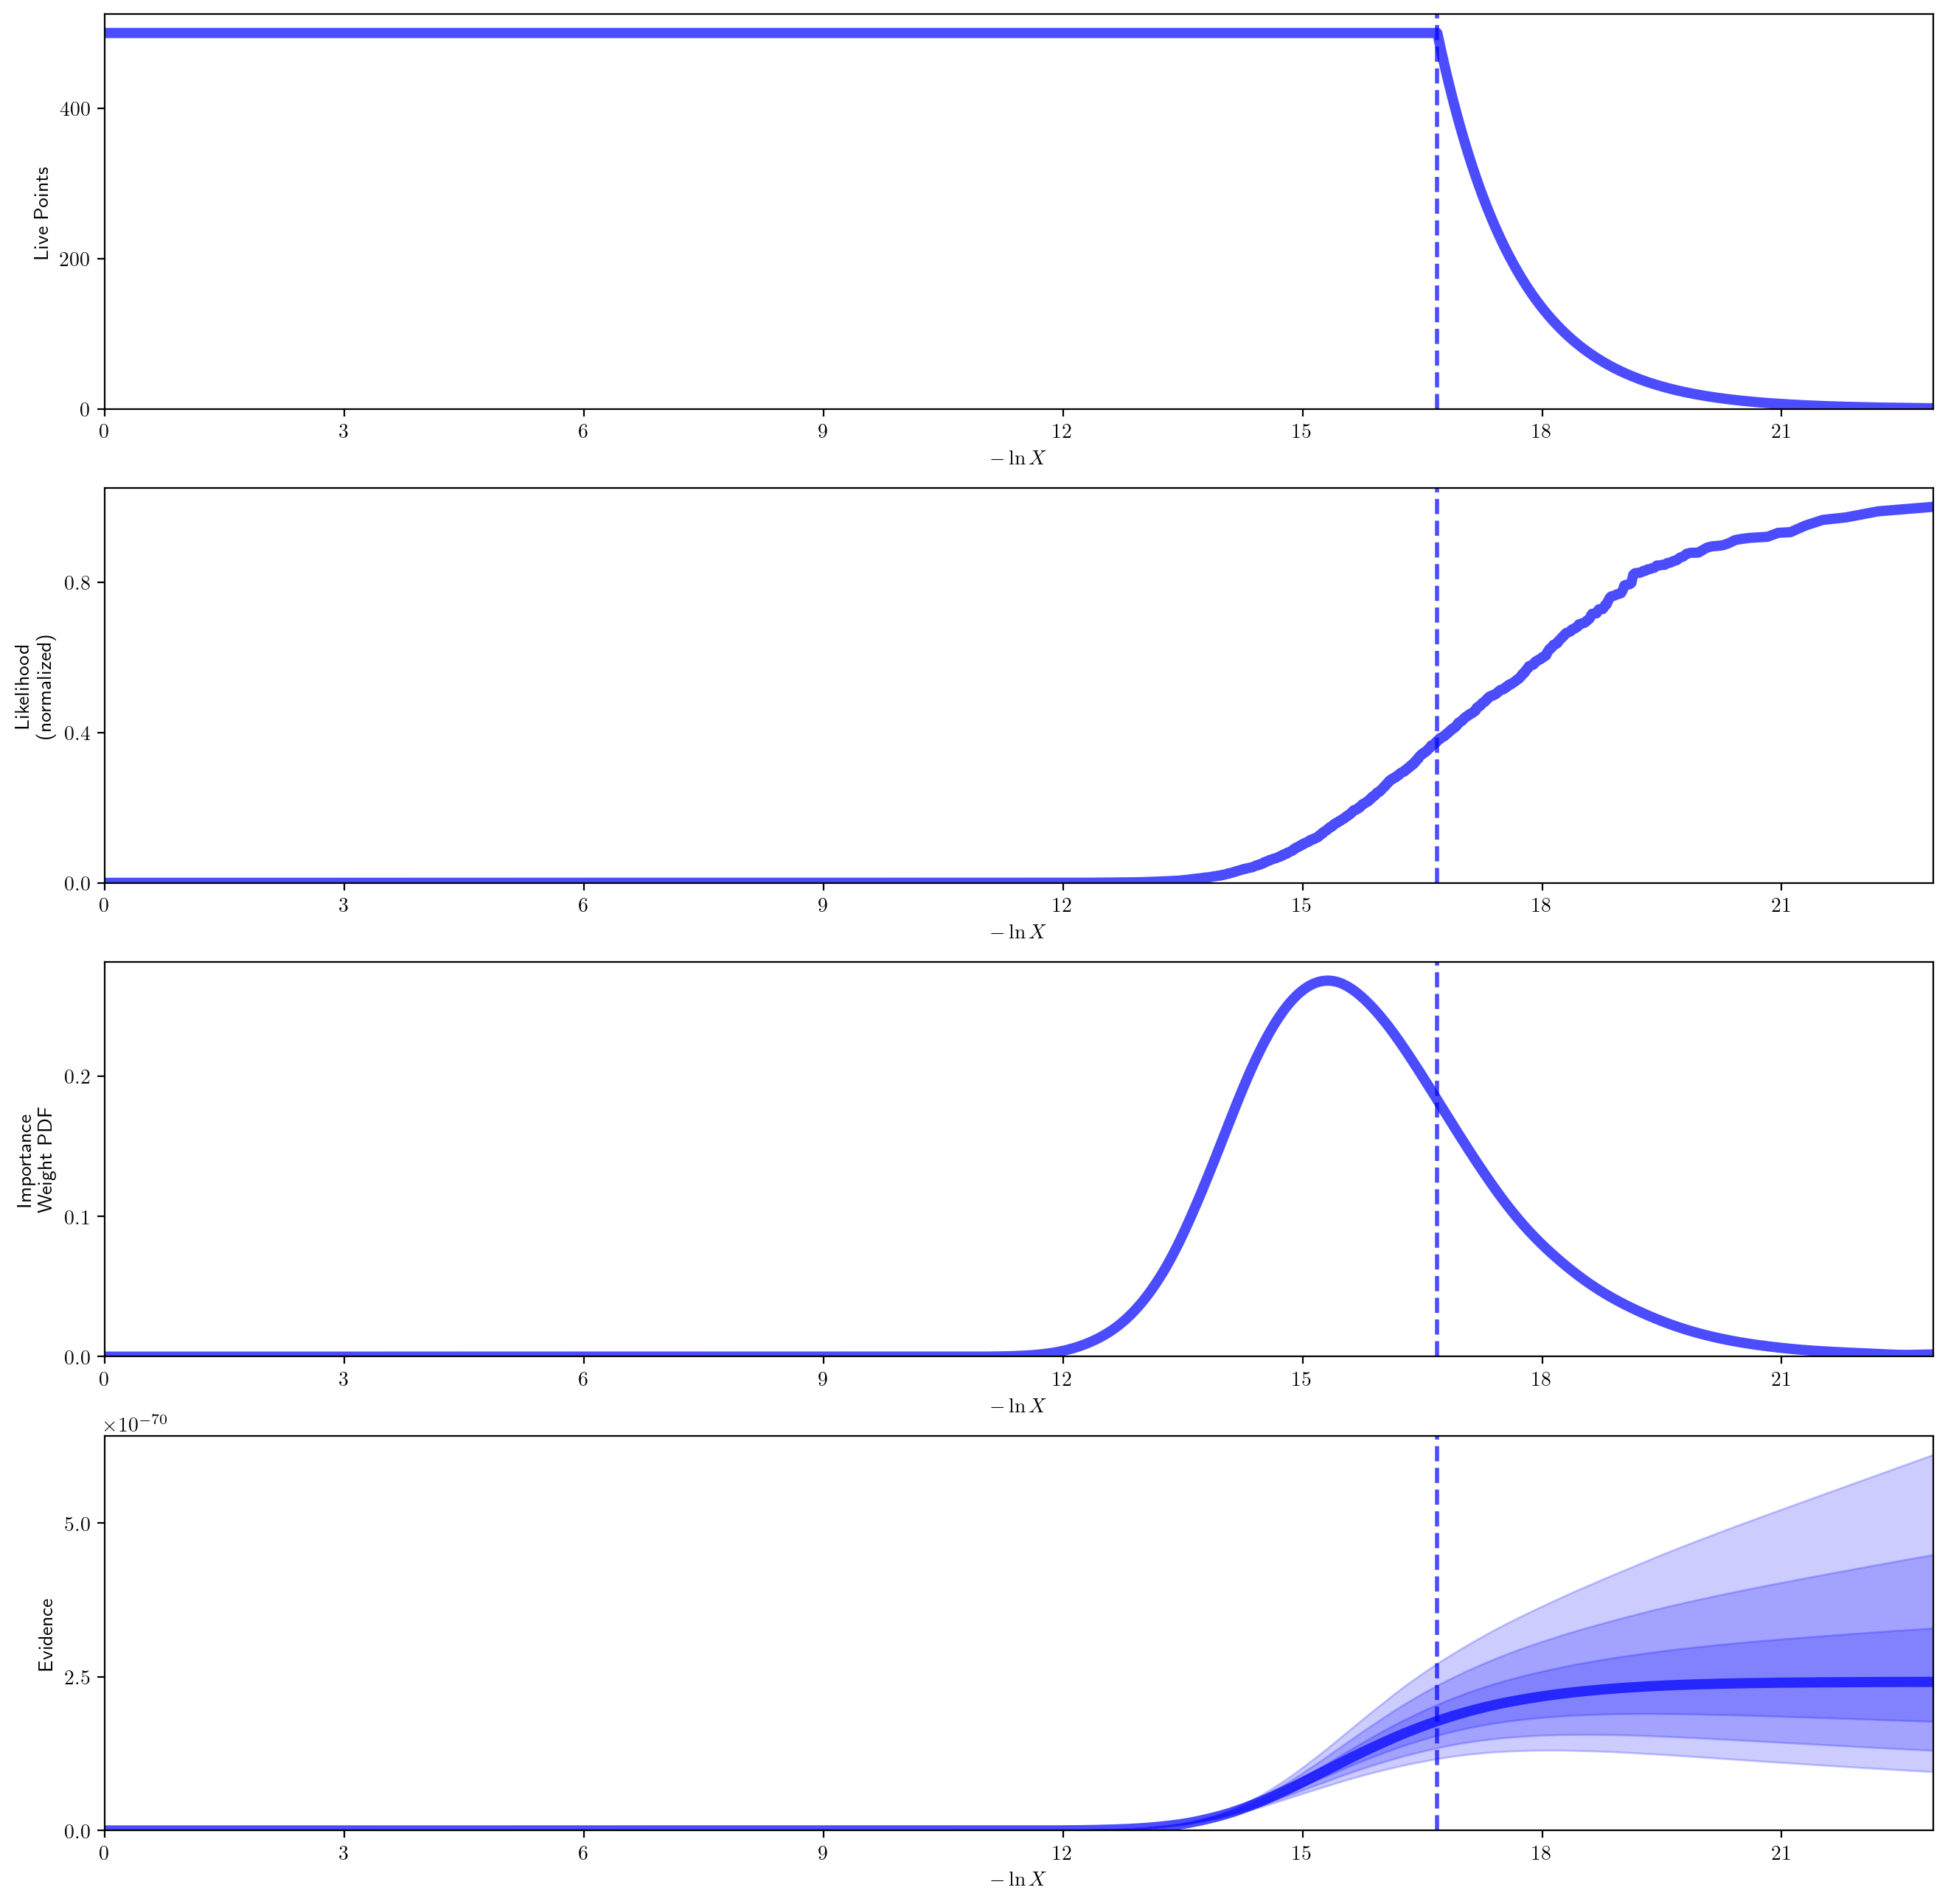

In [11]:
rfig, raxes = dyplot.runplot(sresults_gauss)

Text(0.5, 0.98, 'Parameter traces')

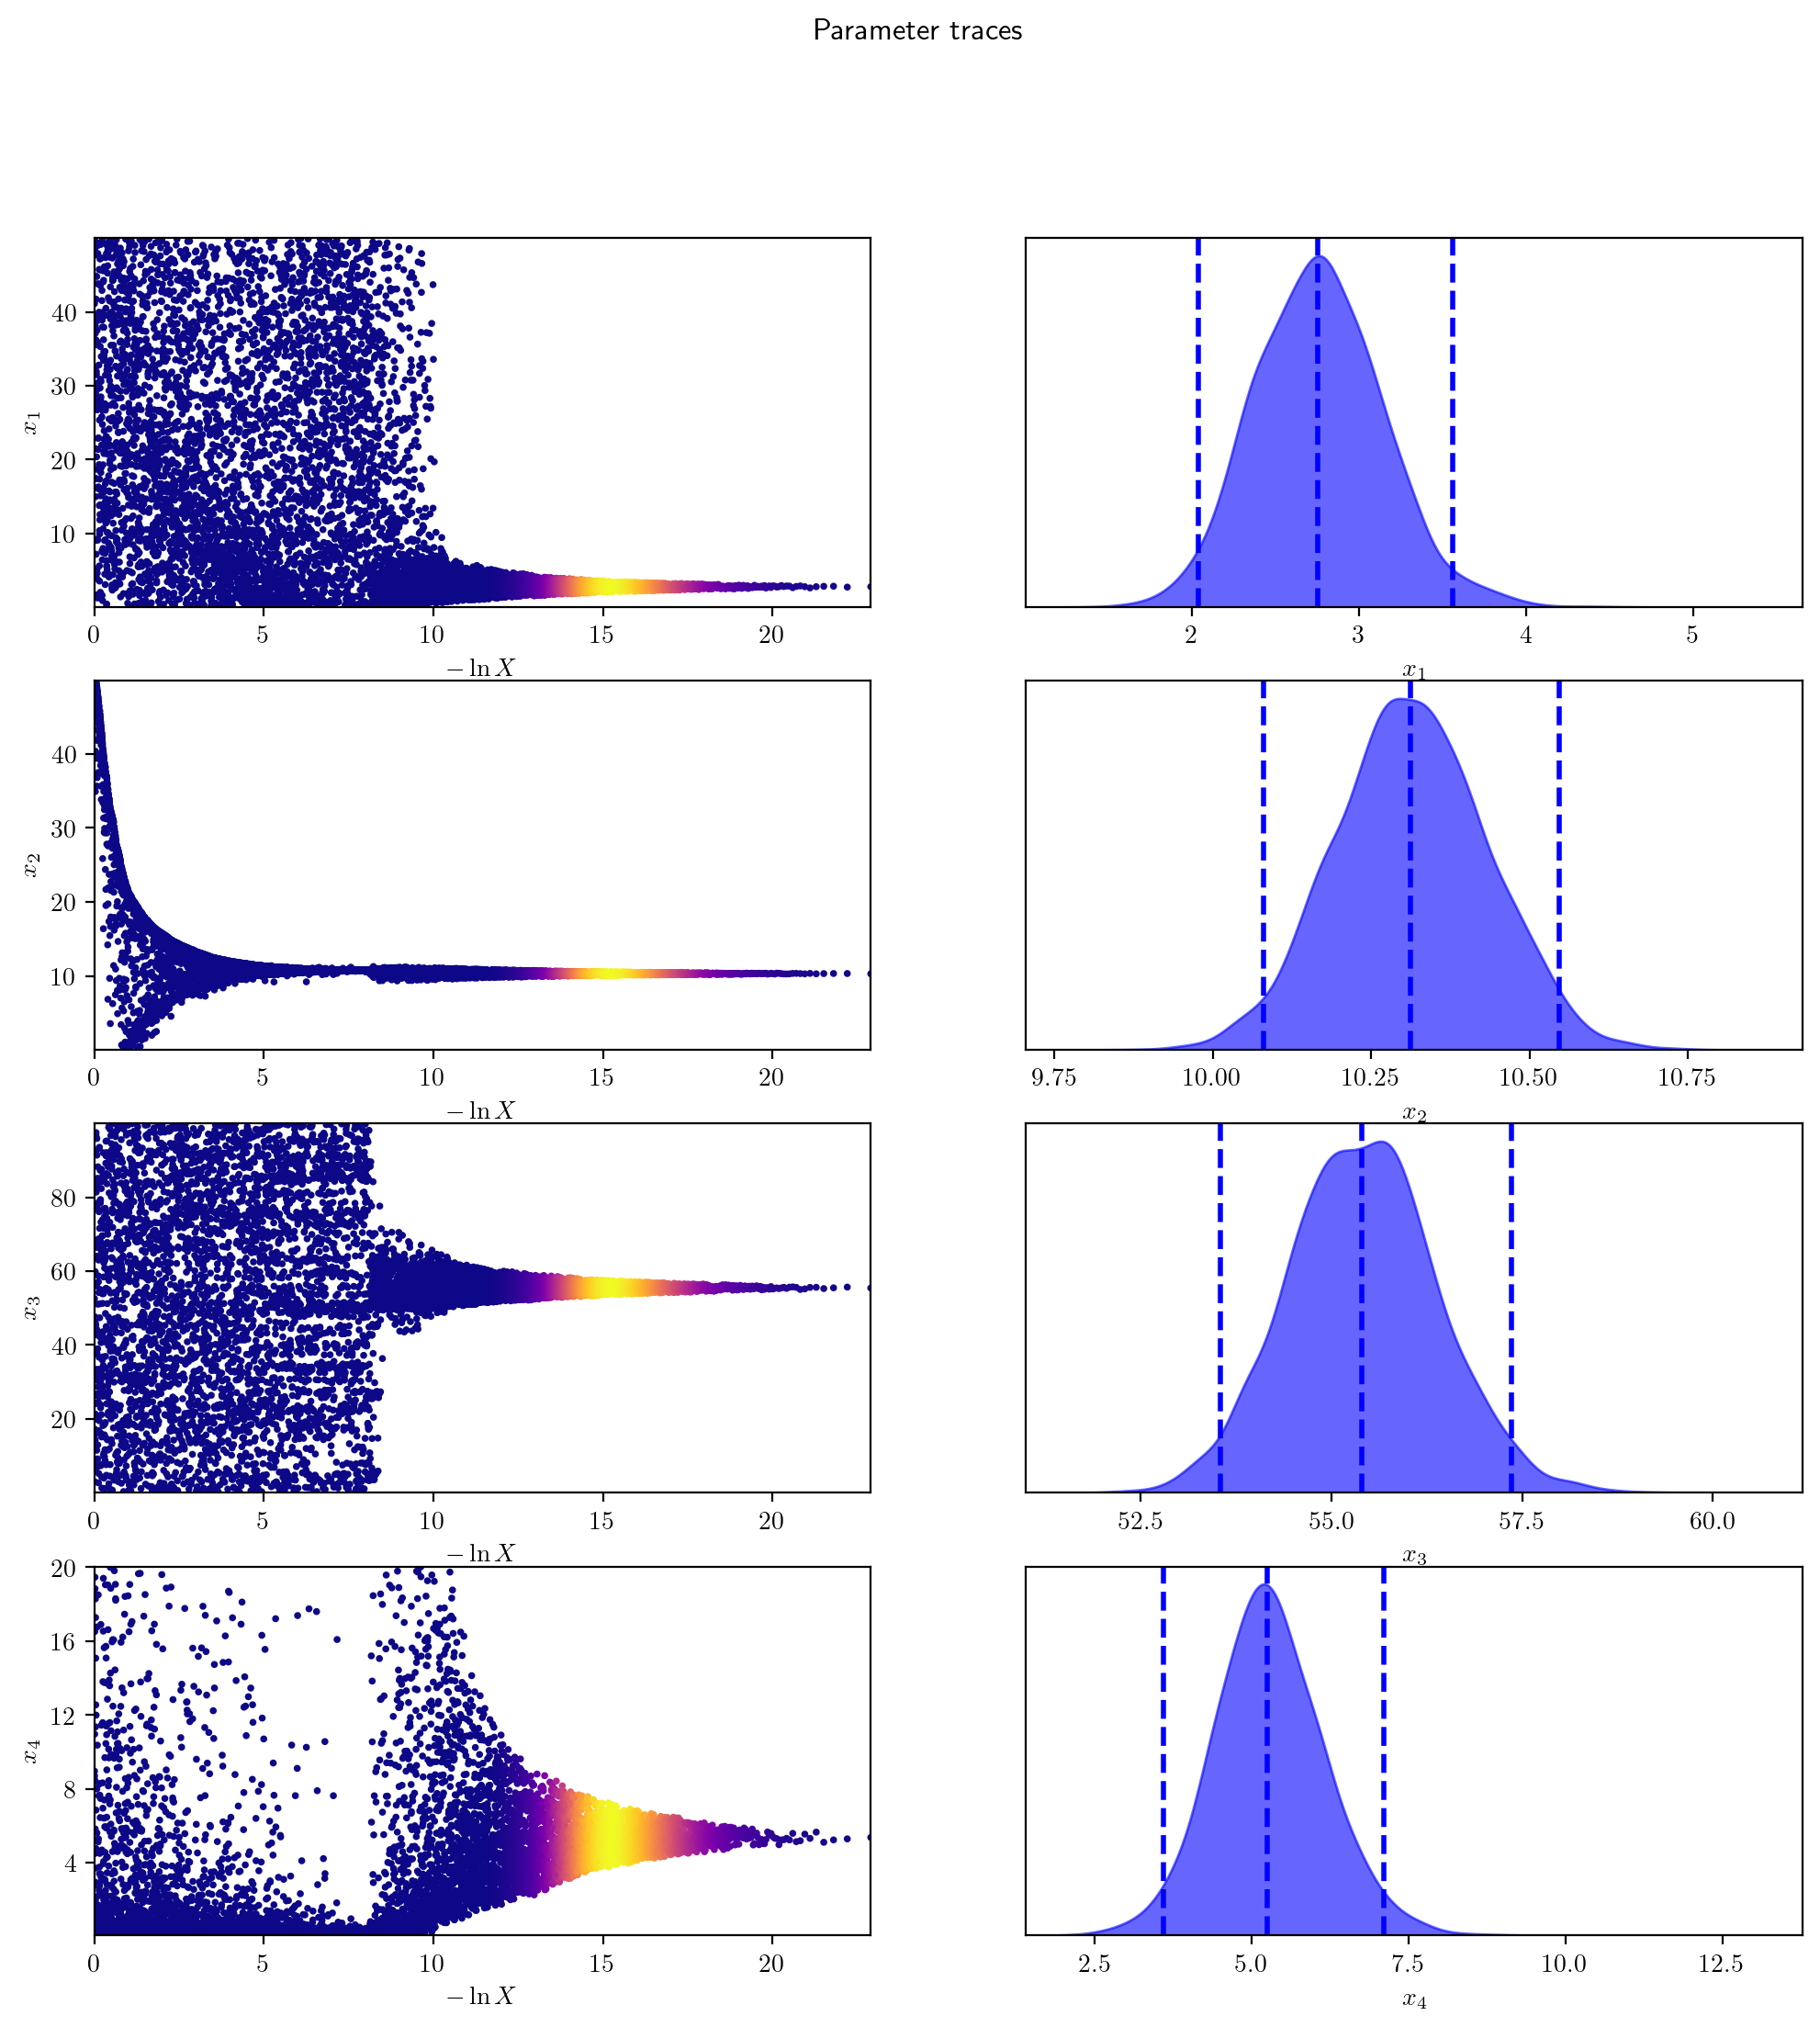

In [12]:
tfig, taxes = dyplot.traceplot(sresults_gauss)
plt.suptitle('Parameter traces')

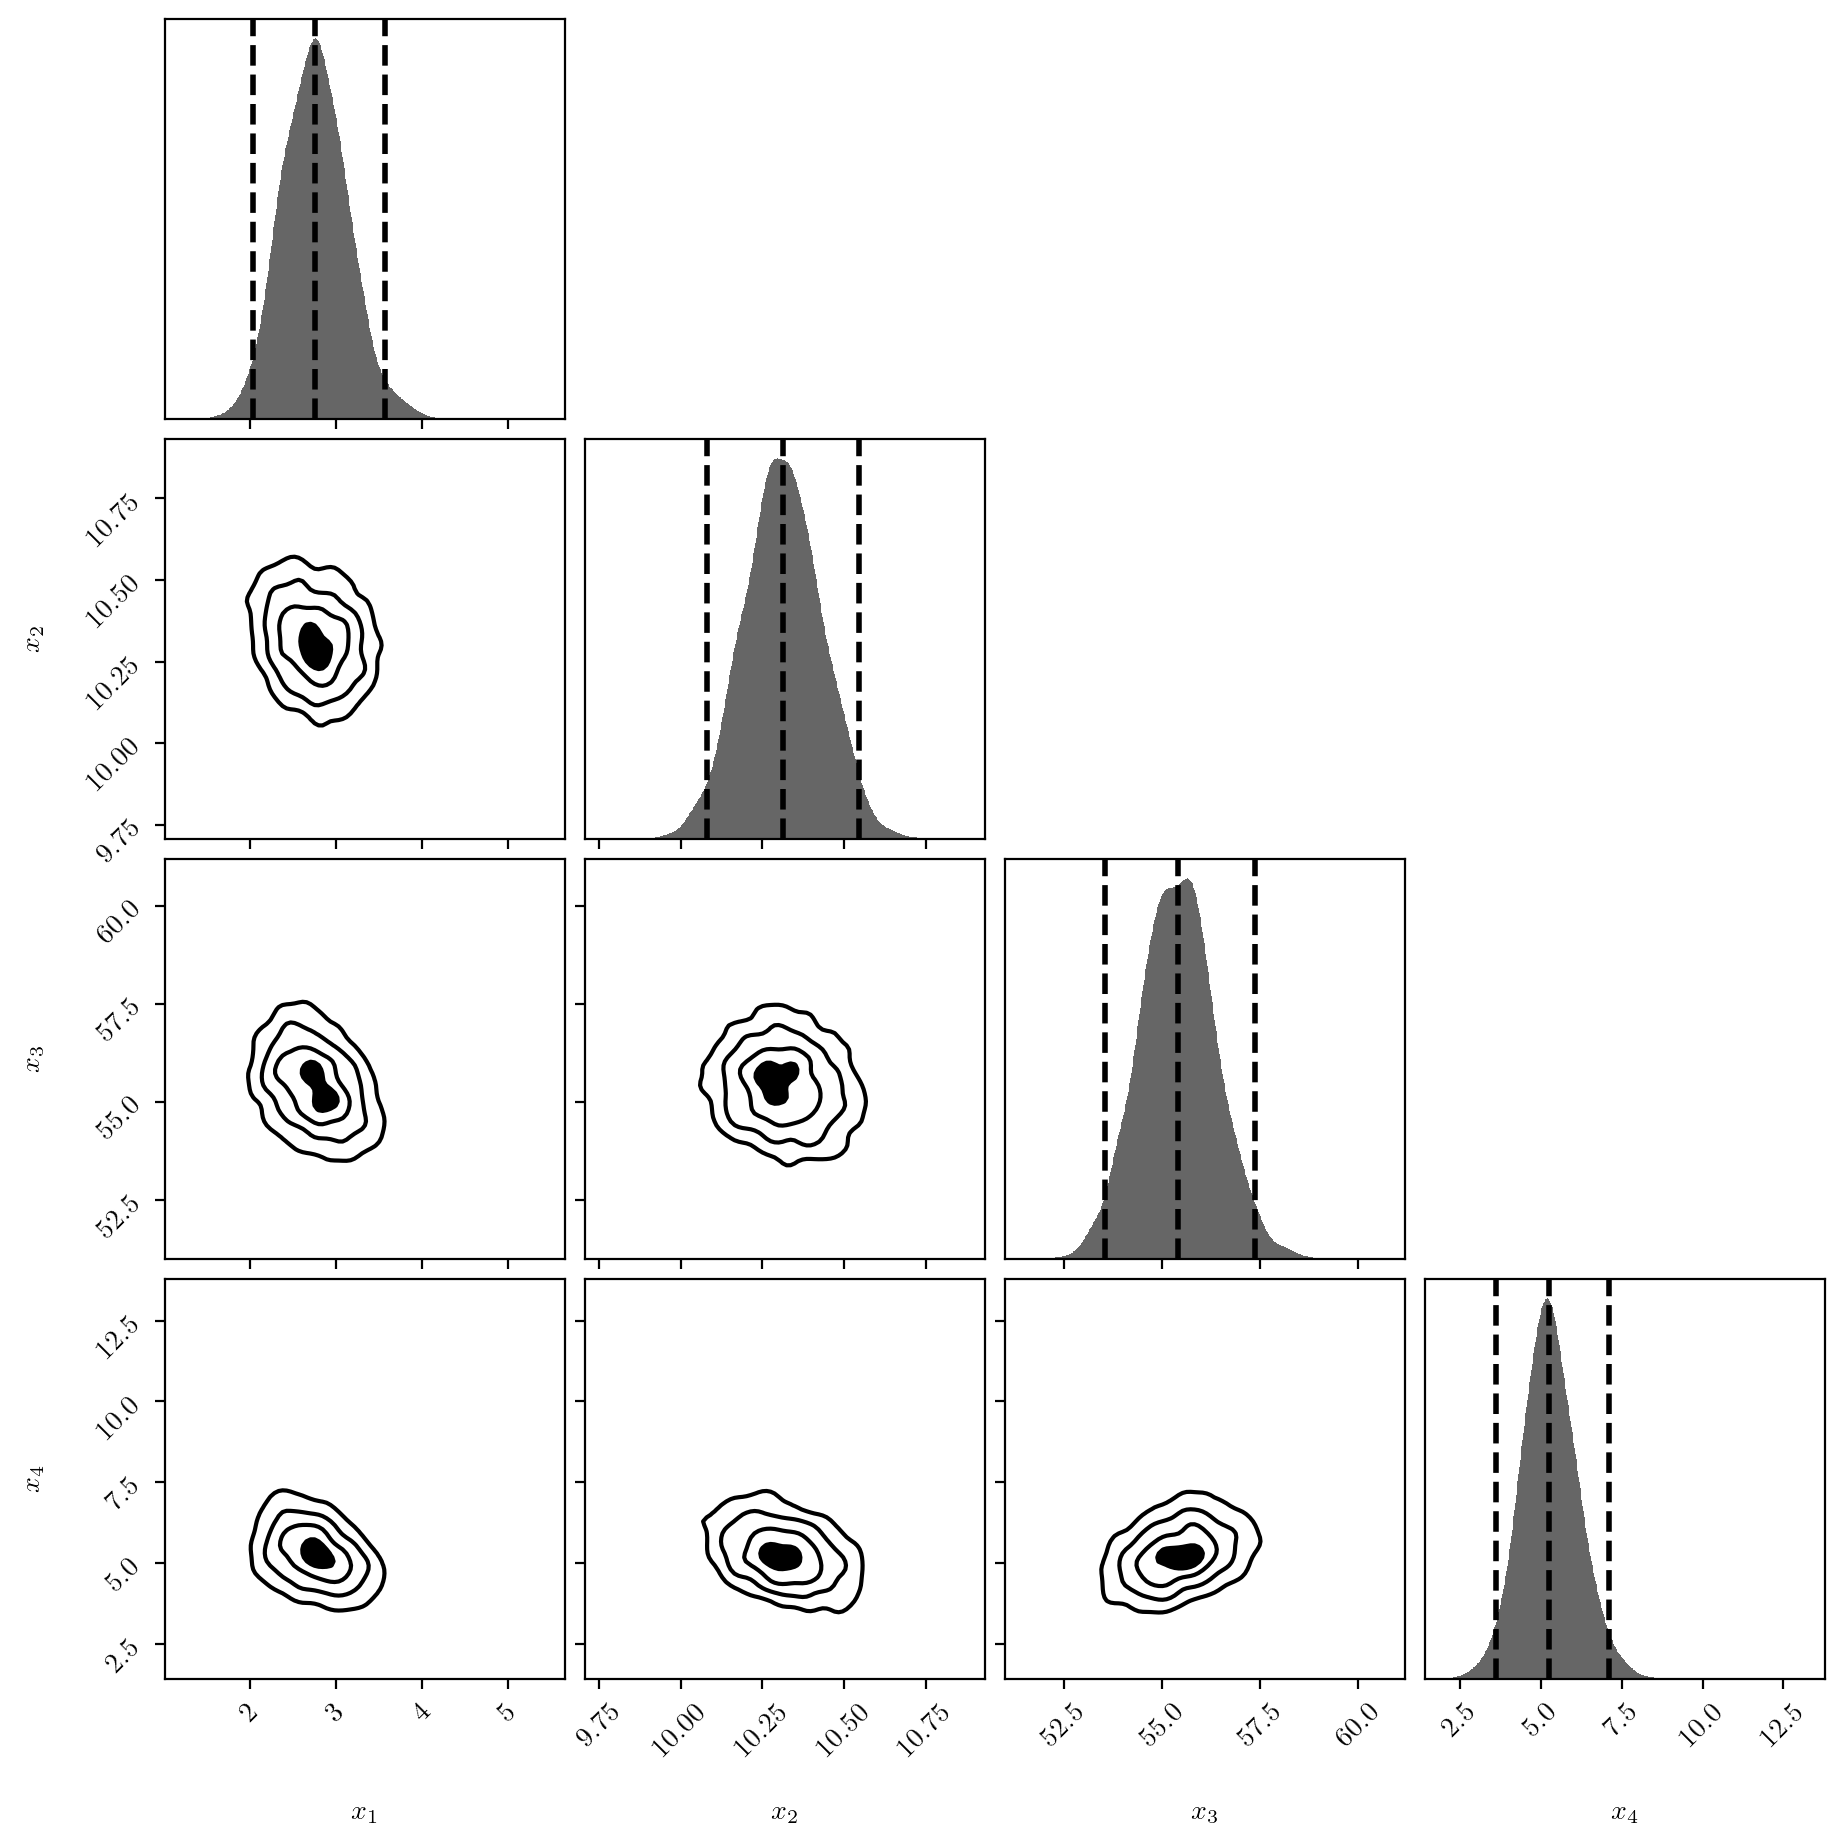

In [13]:
cfig, caxes = dyplot.cornerplot(sresults_gauss)


9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [ ]:
#print(sresults.logz[-1]) #log of evidence

ratio = np.exp(sresults.logz[-1])/np.exp(sresults_gauss.logz[-1])
print('Odds ratio = ', ratio)
# with equal prior odds over the models: odds ratio = Bayes factor
print('Decisive evidence supporting the burst model')

Odds ratio =  151.52831536763483
Decisive evidence supporting the burst model
